#### Hypothesis: Discover semantic subcategories in ulabeled driving data using unsupervised machine learning.

# 1. Video Introduction

# 2. Introduction (Motivation) and Related Work

The rapid growth of artificial intelligence and machine learning has significantly increased both computational demands and human workloads. Modern deep learning models can require thousands of GPU-days and substantial financial resources to train, while overall computational requirements have increased by more than 300,000 times in recent years [1][2]. In addition, supervised learning approaches often depend on large-scale labeled datasets, which require extensive manual annotation. These constraints motivate the development of unsupervised learning methods that can extract meaningful structure from unlabeled data.

Unsupervised learning and object discovery have been widely studied in prior work. Clustering-based approaches such as DeepCluster [3] demonstrate that visual features can emerge by iteratively grouping feature representations. More recent work extends this idea to real-world scenarios, including temporal and multi-view data, where consistency across time can be leveraged as a supervisory signal [4]. Other approaches formulate object discovery as a similarity optimization problem across images [5] or use clustering to generate assignment targets for representation learning [6]. These works collectively demonstrate that meaningful semantic structure can emerge from unlabeled data through clustering and representation learning and are similar to the approach used in this project.

This paper builds on these ideas and presents a framework for unsupervised learning applied to real-world driving data. The proposed pipeline consists of three stages: 
+ (1) object extraction 
+ (2) object segmentation
+ (3) unsupervised clustering. 

Input to the system is a directory containing `.mp4` files from a Tesla dashcam system, from which frames are extracted and processed. Objects are localized and segmented into candidate regions using `YOLO`, which are then embedded using a self-supervised vision transformer (`DINO`). This approach produces feature vectors with semantic structure. Clustering using DBSCAN then groups similar features into subclasses without requiring labeled data.

The effectiveness of the proposed approach is demonstrated using 2,288 video files collected between January 2025 and May 2025. From this dataset, 1,585 object crops were extracted and grouped into 26 subclasses. The resulting clusters exhibit semantically meaningful structure, indicating that the pipeline is capable of discovering object categories directly from unlabeled data.

## 2.1 Links to Related Work
+ [DeepCluster](https://openaccess.thecvf.com/content_ECCV_2018/html/Mathilde_Caron_Deep_Clustering_for_ECCV_2018_paper.html)
+ [4D Object Discovery](https://proceedings.neurips.cc/paper_files/paper/2022/file/e7407ab5e89c405d28ff6807ffec594a-Paper-Conference.pdf)
+ [Unsupervised Object Discovery](https://arxiv.org/pdf/1904.03148)
+ [Unsupervised Feature Learning](https://arxiv.org/pdf/2006.09882)
+ [Unsupervised Object Re-Identification](https://ojs.aaai.org/index.php/AAAI/article/view/28092)

# 3. Theory, Metric Definition, and Background Information

The following sections provide a theoretical understanding of the proposed approach and its evaluation metrics.

## 3.1 Pipeline Overview

The proposed system performs object discovery using a three-stage pipeline: 
+ object extraction
+ feature embedding
+ clustering

Objects are located and segmented using a pretrained detector (`YOLO`), then embedded into a semantic feature space using a self-supervised vision transformer (`DINO`). Finally, density-based clustering (`DBSCAN`) is applied to group similar objects into subclasses without labeled data. The tasks are implemented separately in:

+ extraction.py
+ segmentation.py
+ learning.py

The entire pipeline is then implemented in `pipeline.py`.

## 3.2 Object Detection (YOLO)

Object localization is performed using YOLO (You Only Look Once), a single-stage object detector that predicts bounding boxes and class probabilities in a single forward pass [7]. Given an input image $I$, YOLO produces a set of detections:

$$
D(I) = \{(b_i, c_i, s_i)\}_{i=1}^{N}
$$

where $b_i = (x_{1i}, y_{1i}, x_{2i}, y_{2i})$ is the predicted bounding box, $c_i$ is the predicted class label, $s_i \in [0,1]$ is the confidence score, and $N$ is the number of detections retained after confidence filtering and non-maximum suppression.

In this work, detections are used to extract candidate object regions:

$$
x_i = I[b_i]
$$

where $x_i$ denotes the image crop corresponding to bounding box $b_i$. Detections are filtered using a loose detection threshold of `0.5`. Crops that exceed this value are passed to the feature extraction stage. The detector is therefore used as an object proposal mechanism rather than as the final classifier. An example output is shown in Figure 1.

<div style="text-align: center;">
    <img src="jupyter_source_files\traffic_object_detection_fig_1.png" width="600"/>
    <p><b>Figure 1:</b> Traffic object detection using YOLO.</p>
</div>

# 3.3 Feature Extraction (DINO)

Feature extraction is performed using a self-supervised vision transformer (`DINO`), which maps an input image $x$ to a feature vector in a high-dimensional space [8]:

$$
f(x) \in \mathbb{R}^d
$$

The resulting feature vectors are L2-normalized:

$$
\hat{f}(x) = \frac{f(x)}{\|f(x)\|}
$$

This normalization enables the use of cosine similarity as a distance metric:

$$
d(x_i, x_j) = 1 - \langle \hat{f}(x_i), \hat{f}(x_j) \rangle
$$

DINO embeddings are known to capture high-level semantic structure without requiring labeled data, making them well-suited for clustering-based object discovery. In the code, features are normalized in `learning.py` within the `embed()` function when returning the final value.

## 3.4 Clustering (DBSCAN)

Clustering is performed using DBSCAN, a density-based clustering algorithm [8]. Given a distance metric $d(x_i, x_j)$, DBSCAN defines clusters based on two parameters: $\varepsilon$ (neighborhood radius) and $\text{min\_samples}$.

The $\varepsilon$-neighborhood of a point $x_i$ is defined as:

$$
\mathcal{N}_\varepsilon(x_i) = \{x_j \mid d(x_i, x_j) \leq \varepsilon \}
$$

A point is classified as:
- a **core point** if $|\mathcal{N}_\varepsilon(x_i)| \geq \text{min\_samples}$ (including the point itself)
- a **border point** if it is not a core point but lies within the $\varepsilon$-neighborhood of a core point
- a **noise point** if it is neither a core point nor a border point

In the approach presented here, cosine distance or Euclidean distance is selected based on the results of hyperparameter tuning.

$$
d_{\text{cosine}}(x_i, x_j) = 1 - \langle \hat{f}(x_i), \hat{f}(x_j) \rangle
$$

$$
d_{\text{euclidean}}(x_i, x_j) = \|f(x_i) - f(x_j)\|
$$

Clusters consist of core points, and border points are assigned to a neighboring cluster.

## 3.5 Metric Definition

To evaluate clustering performance without ground truth labels, a composite objective function is defined that balances intra-cluster compactness, inter-cluster separation, and cluster size distribution.

Let $C_1, \dots, C_K$ denote the set of clusters, and let $\mu_k$ denote the centroid of cluster $C_k$:

$$
\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} \hat{f}(x_i)
$$

The average within-cluster distance is defined as:

$$
D_{\text{within}} = \frac{1}{K} \sum_{k=1}^{K} \frac{1}{|C_k|} \sum_{x_i \in C_k} d(x_i, \mu_k)
$$

where $d(x_i, \mu_k)$ denotes the distance between point $x_i$ and centroid $\mu_k$ using the selected distance metric (cosine or Euclidean).

The average between-cluster distance is defined as:

$$
D_{\text{between}} =
\frac{1}{K(K-1)}
\sum_{i=1}^{K} \sum_{\substack{j=1 \\ j \ne i}}^{K} d(\mu_i, \mu_j)
$$

To account for cluster size imbalance, a dominance term is defined as:

$$
\text{dominance} = \frac{\max_k |C_k|}{\sum_{k=1}^{K} |C_k|}
$$

The final objective function is defined as:

$$
J = \log(1 + K) \cdot \frac{D_{\text{between}}}{D_{\text{within}} + \epsilon} \cdot (1 - \text{dominance})
$$

where $\epsilon$ is a small constant to avoid division by zero.

In practice, distances are generally normalized. However, the ratio of $D_{\text{within}}$ to $D_{\text{between}}$ remains scale-invariant. Therefore, no normalization is applied.

This objective function rewards:
- low intra-cluster distance (compact clusters)
- high inter-cluster distance (well-separated clusters)
- a larger number of clusters
- reduced dominance of any single cluster

This formulation is designed to encourage the emergence of meaningful sub-classes within the dataset.

## 3.7 Implementation Differences

The implementation in this work differs from standard clustering methods discussed in class in several key ways. 

First, clustering is performed on high-dimensional feature embeddings generated by a self-supervised vision transformer (`DINO`), rather than on raw feature vectors. This enables the grouping of semantically similar objects rather than relying solely on low-level features.

Second, `DBSCAN` is used as the clustering algorithm, rather than K-means. Unlike K-means, `DBSCAN` does not require specifying the number of clusters in advance and is capable of identifying clusters of arbitrary shape while also detecting noise points.

Third, a custom objective function is introduced to evaluate clustering quality in the absence of ground truth labels. This differs from standard evaluation metrics, which typically assume labeled data or predefined structure.

Finally, cosine distance is used as the primary similarity metric, leveraging L2-normalized feature vectors. This differs from the Euclidean distance commonly used in traditional clustering approaches and allows clustering to be based on angular similarity in feature space. It is worth noting that Euclidean distance is an accepted option when performing DBSCAN, but the objective function uses only cosine distance.

## 3.8 Dataset Description

The dataset used in this work consists of front-facing Tesla dashcam video collected between January 2025 and May 2025. The videos capture real-world driving conditions, including varying lighting, weather, and traffic environments.

Frames are extracted from the videos by defining temporal pools (i.e., 30 seconds) and extracting the most desirable frame from each window. Slight encoding differences resulting from the timing of the in-vehicle save command resulted in slight sharpness variations within each window. Additionally, the temporal pooling approach used is expandable to multiple alternate collection methods. For example, if each camera were allowed to collect data, it could be used to select frames among the available sensors. A multi-sensor collection effort could also be deconflicted by pooling in three dimensions by adding a spatial component.

Object regions are then identified and cropped using a pretrained object detector. These crops serve as input to the feature extraction and clustering pipeline. The dataset is unlabeled, making it suitable for evaluating unsupervised learning methods.

## 3.9 Correctness and Validation

Correctness of the implementation is evaluated through both quantitative and qualitative analysis.

Quantitatively, the objective function is used to assess clustering performance. Higher values of the objective correspond to improved cluster structure, characterized by lower intra-cluster distances and higher inter-cluster distances.

Qualitatively, clustering results are visually inspected to ensure that samples within the same cluster exhibit semantic similarity. For example, clusters are expected to group similar traffic objects such as signs, signals, or road features.

Additionally, the behavior of DBSCAN is verified by varying its parameters. Decreasing $\varepsilon$ results in more fragmented clusters, while increasing $\varepsilon$ merges clusters. The ability to correctly identify noise points further confirms proper implementation.

Together, these checks provide confidence that the clustering pipeline is functioning as intended. The final output consists of a set of images depicting object groupings and a table summarizing clustering results.

# 4. Approach, Implementation, and Results

## 4.1 Experimental Setup

The proposed pipeline was evaluated using object crops extracted from dashcam footage. Object crops were generated and embedded using a pretrained DINO model. Clustering was performed using DBSCAN, with hyperparameters tuned over a range of values for $\varepsilon$, $\text{min\_samples}$, and distance metric (cosine and Euclidean).

The objective function defined in Section 3.5 was used to evaluate clustering quality. The metric balances intra-cluster compactness, inter-cluster separation, and cluster size distribution.

The implementation is broken into three main steps:

+ Data extraction (frames from video)
+ Object detection and cropping
+ Feature extraction and clustering

The full code to execute this pipeline is provided alongside this tutorial.

## 4.2 Environment Setup

Prior to running any code, the following dependencies must be installed from *requirements.txt*. This can be done by creating a new virtual environment and running `pip install -r requirements.txt`.

The dependencies are imported into the provided code in the correct places. No additional import commands are required.

## 4.3 Data Extraction

The data extraction task is implemented in `extraction.py`. For all of the code presented in this Jupyter notebook, the user has the option of running each file separately, relying on the main method, or running the `pipeline.py` file that automates this task.

The `Extractor()` class in `extraction.py` handles the entire data extraction process via the `run()` method. The user should be aware of the following critical parameters prior to running the code:

+ input_dir: The path to the input directory containing .mp4 files.
+ output_dir: The path to the output directory to save frames from the .mp4 files.
+ yolo_model: The path to the YOLO model to use for initial object detection.
+ preserve_data: When true, the entire dataset is overwritten; otherwise, only new data is added.
+ verbose (bool): When true, verbose output is printed to the console.
+ temporal_window_size (int): The size of the window used to pool frames.

Unlike the object identification and clustering tasks, the data extraction task presented here is effective but not optimized. Derivative products of the pipeline presented here will require modifications to the handling of data. Therefore, for the sake of time, extraction was made repeatable but not optimal.

### 4.3.1 Data Extraction Challenges

Data extraction proved to be a time-consuming task requiring several methods to ensure integrity of the dataset.

#### 4.3.1.1 Redundant Artifacts

Visual inspection of extracted frames revealed a consistent dark region at the bottom of each image. This region does not contain meaningful information and remains largely constant across frames.

Example dark regions:

<table>
<tr>
<td><img src="jupyter_source_files\2026-01-13_08-44-47-front_01083_marked.jpg" width="600"></td>
<td><img src="jupyter_source_files\2026-01-13_08-44-47-front_01819_marked.jpg" width="600"></td>
</tr>
</table>

If left unaddressed, this artifact could introduce bias into the pipeline by contributing non-informative and repetitive visual patterns to the embeddings, potentially degrading clustering performance.

To mitigate this issue, each frame is cropped to 92.5% of its original height, removing the lower portion of the image where the artifact is present. This ensures that only relevant portions of each image are retained for downstream processing. The images above are shown below with this cropping applied.

<img src="jupyter_source_files\corrected_images.png" width="1200">

#### 4.3.1.2 Duplicate Frames

To reduce redundancy in the dataset, a lightweight duplicate frame detection step was applied. Rather than comparing each frame against all previously extracted frames, comparisons were restricted to a small, recent window of accepted frames. The sliding window, in combination with temporal pooling, still allows for objects to be ingested into the dataset if encountered at different times. For example, an image of the same scene may be accepted multiple times if encountered on different days. This design is intentional, as multiple observations over time represent a pattern within the data and mirror common human learning behavior.

Similarity between frames was evaluated using the mean absolute error (MAE) between pixels. Frames with differences below a predefined threshold were considered near-duplicates and excluded from the dataset. Empirical evaluation indicated that a threshold of approximately 25 effectively removed most redundant frames while preserving meaningful variation.

This approach effectively removes visually similar frames while maintaining natural diversity in the data, without introducing significant computational overhead.

#### 4.3.1.3 Motion Blur

Due to vehicle motion and compression artifacts in dashcam footage, many frames exhibit varying degrees of motion blur. This reduces the amount of high-frequency detail present in the image and can negatively impact downstream tasks such as feature extraction and clustering.

To address this, each candidate frame is evaluated using the Laplacian variance of its grayscale representation. The Laplacian operator highlights regions of rapid intensity change (edges), and the variance of this response provides a quantitative measure of image sharpness.

Frames with a variance below a predefined threshold are considered blurry and are excluded from the dataset, while frames exceeding the threshold are retained. Empirical testing indicated that a threshold of approximately 200 provided a good balance between dataset size and image quality. Further tuning of this value may improve this balance.

This filtering step ensures that only frames with distinct edges are used for feature extraction, improving the consistency and reliability of the resulting visual embeddings.

#### 4.3.1.4 Dataset Visualization

The code below can be executed repeatedly to view frames that were generated from this the `Extractor()` class. Modifying the `grid_size` parameter allows for a different number of images to be displayed.

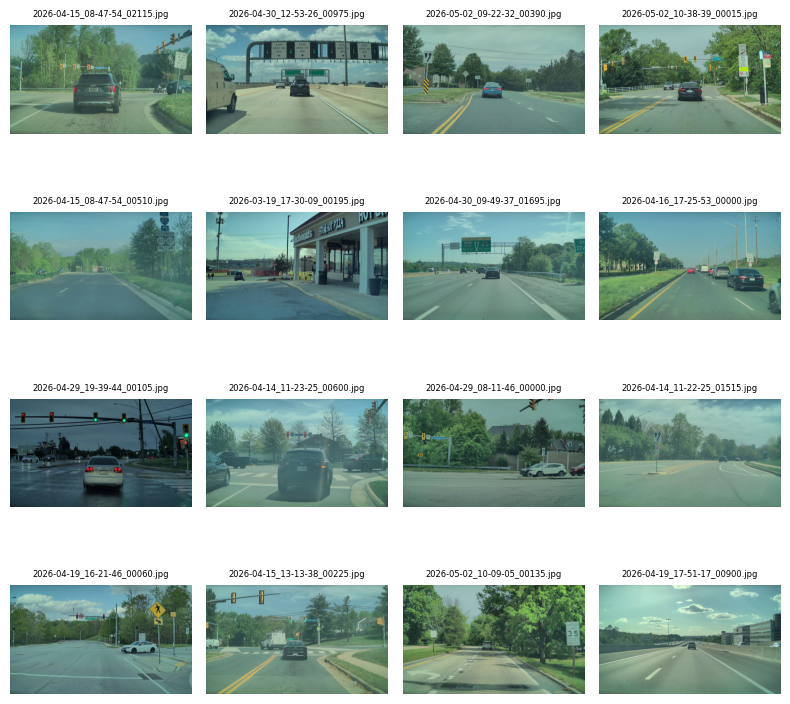

In [3]:
import os
import random
import cv2
import matplotlib.pyplot as plt

frame_dir = "extracted_static"
grid_size = 4

image_files = [f for f in os.listdir(frame_dir)]

n_images = grid_size * grid_size
selected = random.sample(image_files, min(n_images, len(image_files)))

fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    if i >= len(selected):
        ax.axis("off")
        continue

    img_path = os.path.join(frame_dir, selected[i])
    img = cv2.imread(img_path)

    if img is None:
        ax.axis("off")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(selected[i], fontsize=6)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4.4 Data Segmentation

The frames generated by the `Extractor` class are divided into segments using a YOLO model trained on two generic classes. However, the YOLO model could easily be retrained on the final result of the pipeline to complete additional training iterations.

+ Class A: All signs
+ Class B: All traffic signals

The segmentation task is performed in `segmentation.py` by the `Cropper()` class. The user should be aware of the following parameters prior to running the code:

+ yolo_model: The path to the YOLO model to use for object detection.
+ input_dir (str): The path to the input directory containing full frames.
+ output_dir (str): The path to the output directory to save the object crops.
+ verbose (bool): When true, verbose output is printed to the console.

Running the code provided in `segmentation.py` will generate object crops for each frame in the input directory. The crops are saved in the output directory, beginning with the filename of the input frame and ending with the ID of the identified class and an index representing the number of times the class was detected in the frame. For example, *2026-01-13_08-39-45_00870_generic_class_a_0_0*.

### 4.4.1 Data Segmentation Challenges

The segmentation task proved to be the simplest task throughout the pipeline. However, the challenge of blurry images remained. This problem was handled the same way as in data extraction (4.3.1.3 Motion Blur), except a higher threshold was used to filter out blurry images due to the smaller size of the object crop compared to the full frame.

Empirical testing revealed that 5000 filtered out enough blurry images to achieve a good balance between dataset size and image quality. This task is implemented in the `laplacian_variance()` and `is_blurry()` methods of the `Cropper()` class.

### 4.4.2 Data Segmentation Results

The code below can be executed repeatedly to view object crops that were generated from the `Cropper()` class. The `grid_size` parameter allows for a different number of images to be displayed.

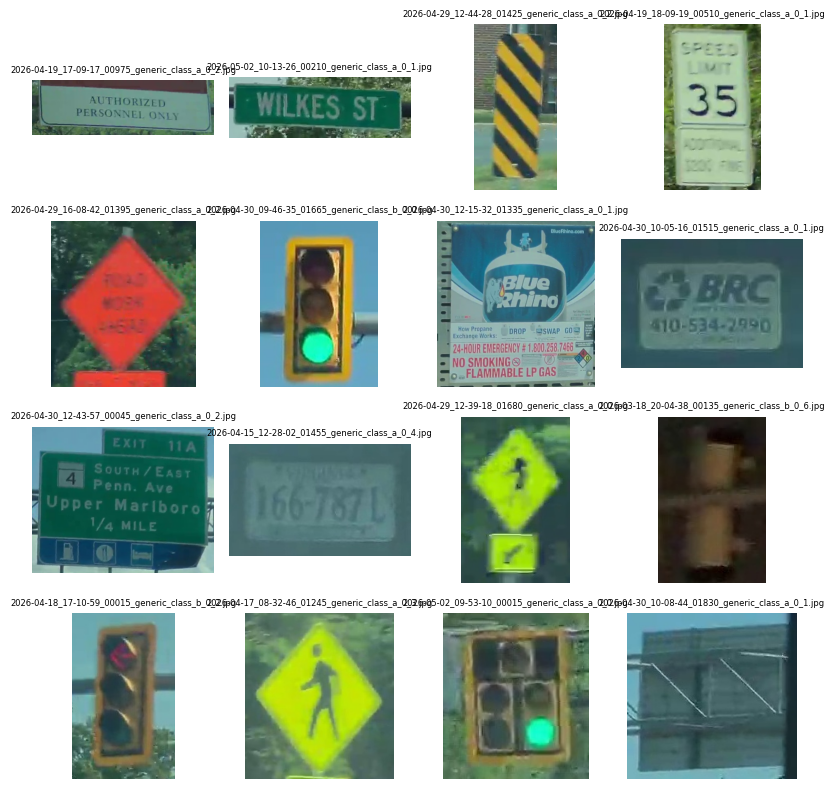

In [4]:
import os
import random
import cv2
import matplotlib.pyplot as plt

frame_dir = "crops_static"
grid_size = 4

image_files = [f for f in os.listdir(frame_dir)]

n_images = grid_size * grid_size
selected = random.sample(image_files, min(n_images, len(image_files)))

fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    if i >= len(selected):
        ax.axis("off")
        continue

    img_path = os.path.join(frame_dir, selected[i])
    img = cv2.imread(img_path)

    if img is None:
        ax.axis("off")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(selected[i], fontsize=6)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4.5 Object Identification (Clustering)

The object crops generated by the `Cropper()` class are ingested by the `DinoClusterer()` class. `DinoClusterer()` clusters the object crops using DBSCAN to identify similar object crops and saves these clusters for evaluation. The user should be aware of the following parameters prior to running the code:

+ input_dir (str): The path to the input directory containing object crops.
+ output_dir (str): The path to the output directory to save the clusters.
    - `DinoClusterer()` produces two output directories: raw clusters and merged clusters.
+ eps (float): The epsilon value for DBSCAN clustering.
+ min_samples (int): The minimum number of samples required to form a cluster (Min Points).
+ metric (str): The metric to use for DBSCAN clustering. Options: ['cosine', 'euclidean']
+ merge_eps (float): The epsilon value for merging similar clusters.

The `eps` and `min_samples` parameters can be provided to the class, and the user may skip to the `run()` method, but the implementation discussed performs hyperparameter tuning in the `tune()` method to optimize these parameters.

### 4.5.1 Object Identification Challenges

The unsupervised learning portion of the pipeline is the most complex task throughout the pipeline. Pre-existing libraries such as scikit-learn were helpful in resolving some common issues. However, issues specific to this use case remained.

#### 4.5.1.1 Background Noise

Early testing revealed oversensitivity in the DINO embeddings to background noise. To resolve this issue, a Gaussian blur was applied to each image with a slight size reduction prior to embedding. This was done in the `embed()` method via the following code.

```python
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    img = img[int(h*0.1):int(h*0.9), int(w*0.1):int(w*0.9)]

    img = cv2.GaussianBlur(img, (5, 5), 0)

    img = Image.fromarray(img)

#### 4.5.1.2 Hyperparameter Tuning

The overall performance of the pipeline is heavily dependent on the hyperparameters, mainly the distance metric, eps, and min_samples used for DBSCAN. Selecting fixed values for these parameters proved to be ineffective, as different parameters were required for different datasets. Therefore, hyperparameter tuning was performed to find the best values, making the pipeline robust to changing data.

Hyperparameter tuning is conducted in the `tune()` method.

#### 4.5.1.3 Data Management

A subtle but important hurdle throughout the project was the access and storage of data. The pipeline currently operates dependent on a number of directories, which is not ideal for online applications and leaves data vulnerable to accidental deletion or unintentional modification. For the purposes of this project, the architecture was sufficient, but a more robust system should be implemented in the future.

Regardless, the current code is capable of ingesting additional videos while preserving prior data. The user simply needs to add the additional videos to the `Extractor()` input directory and re-run the `pipeline.py` file or run each of the three files in sequential order.

## 4.6 Object Identification (Clustering) Results

## 4.6.1 Tabular Results

Tabular results are provided below and in the `cluster_eval_merged.csv` file. The results show a large number of clusters with varying sizes. The ratio of average within-cluster distance to average between-cluster distance is consistently greater than 1 across all clusters, indicating that inter-cluster distances are significantly larger than intra-cluster distances, which is preferred.

This behavior suggests that the clusters are well-separated while maintaining compactness, which is a key indicator of meaningful structure. Larger clusters (e.g., clusters 2, 0, and 5) exhibit slightly lower ratios, likely due to increased intra-cluster variation, while smaller clusters tend to have higher ratios, reflecting tighter grouping.

The presence of many small clusters with high separation ratios indicates the emergence of fine-grained semantic subclasses within the data. This supports the hypothesis that unsupervised clustering of DINO embeddings can recover meaningful object groupings without labeled supervision.

It is also reasonable to expect that additional data would further refine these clusters, potentially increasing both the number and stability of the discovered subclasses.

| Cluster | Size | Percent | Avg Within | Avg Between | Ratio |
|--------|------|---------|------------|-------------|-------|
| 2 | 229 | 0.1445 | 0.05822 | 0.29540 | 5.0735 |
| 0 | 124 | 0.07823 | 0.08850 | 0.29540 | 3.3379 |
| 5 | 82 | 0.05174 | 0.05927 | 0.29540 | 4.9841 |
| 13 | 26 | 0.01640 | 0.04168 | 0.29540 | 7.0870 |
| 11 | 21 | 0.01325 | 0.05529 | 0.29540 | 5.3431 |
| 10 | 17 | 0.01073 | 0.04900 | 0.29540 | 6.0287 |
| 8 | 15 | 0.00946 | 0.05363 | 0.29540 | 5.5079 |
| 9 | 11 | 0.00694 | 0.04867 | 0.29540 | 6.0698 |
| 4 | 6 | 0.00379 | 0.03095 | 0.29540 | 9.5458 |
| 7 | 6 | 0.00379 | 0.03592 | 0.29540 | 8.2232 |
| 14 | 6 | 0.00379 | 0.02731 | 0.29540 | 10.8157 |
| 1 | 5 | 0.00315 | 0.02772 | 0.29540 | 10.6552 |
| 16 | 5 | 0.00315 | 0.02878 | 0.29540 | 10.2641 |
| 20 | 5 | 0.00315 | 0.03563 | 0.29540 | 8.2904 |
| 17 | 4 | 0.00252 | 0.04165 | 0.29540 | 7.0924 |
| 18 | 4 | 0.00252 | 0.02997 | 0.29540 | 9.8580 |
| 19 | 4 | 0.00252 | 0.02456 | 0.29540 | 12.0287 |
| 24 | 4 | 0.00252 | 0.03921 | 0.29540 | 7.5332 |
| 3 | 3 | 0.00189 | 0.01829 | 0.29540 | 16.1486 |
| 6 | 3 | 0.00189 | 0.01510 | 0.29540 | 19.5562 |
| 12 | 3 | 0.00189 | 0.02114 | 0.29540 | 13.9712 |
| 15 | 3 | 0.00189 | 0.02201 | 0.29540 | 13.4208 |
| 21 | 3 | 0.00189 | 0.02366 | 0.29540 | 12.4840 |
| 22 | 3 | 0.00189 | 0.02334 | 0.29540 | 12.6575 |
| 23 | 3 | 0.00189 | 0.02168 | 0.29540 | 13.6262 |
| 25 | 3 | 0.00189 | 0.02398 | 0.29540 | 12.3160 |

## 4.6.2 Visual Results

The code below can be executed repeatedly to review the clusters presented above. The `grid_size` parameter will not affect the number of images displayed because the summary images are generated and stored during program execution. However, the user can open the cluster directories to view each object associated with a cluster by accessing the corresponding subfolder.

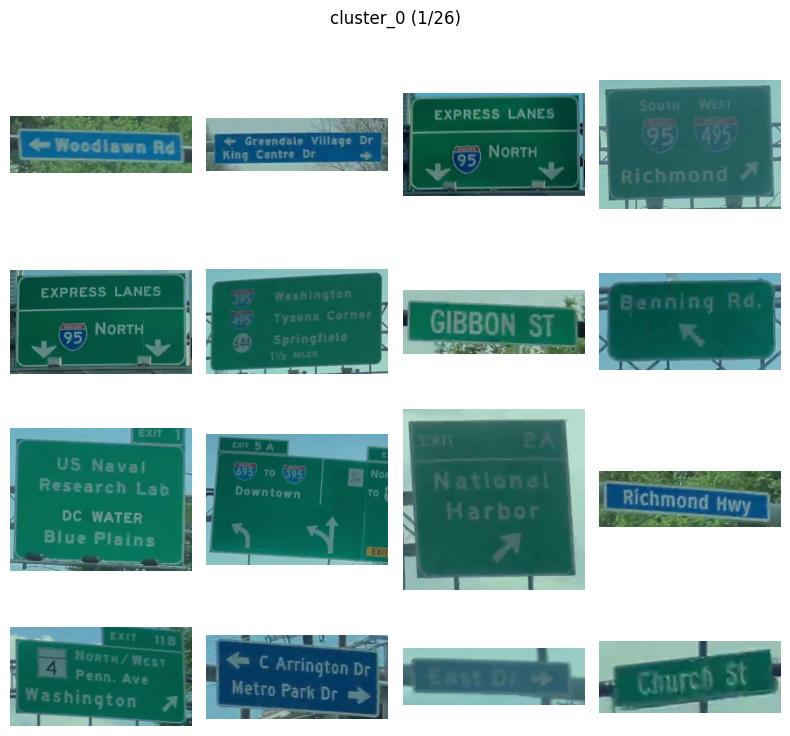

In [5]:
import os
import random
import cv2
import matplotlib.pyplot as plt

cluster_dir = "clusters_merged_static"
grid_size = 4

cluster_folders = sorted([
    d for d in os.listdir(cluster_dir)
    if os.path.isdir(os.path.join(cluster_dir, d))
])

n_clusters = len(cluster_folders)
if n_clusters == 0:
    print("No cluster folders found.")
else:
    try:
        cluster_index
    except NameError:
        cluster_index = 0

    cluster_index = cluster_index % n_clusters

    cluster_name = cluster_folders[cluster_index]
    folder_path = os.path.join(cluster_dir, cluster_name)

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".png", ".jpeg"))
    ]

    if len(image_files) == 0:
        print(f"{cluster_name} is empty.")
    else:
        n_images = grid_size * grid_size
        selected = random.sample(image_files, min(n_images, len(image_files)))

        fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))

        for i, ax in enumerate(axes.flat):
            if i >= len(selected):
                ax.axis("off")
                continue

            img_path = os.path.join(folder_path, selected[i])
            img = cv2.imread(img_path)

            if img is None:
                ax.axis("off")
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.axis("off")

        plt.suptitle(f"{cluster_name} ({cluster_index+1}/{n_clusters})", fontsize=12)
        plt.tight_layout()
        plt.show()

    cluster_index += 1

# 5. Conclusion

This project demonstrated that meaningful visual structure can be recovered from unlabeled data using a largely unsupervised pipeline. By combining temporal frame selection, object detection, DINO feature extraction, and DBSCAN clustering, the pipeline was able to group visually similar objects into coherent clusters without labeled supervision.

Key components contributing to performance included temporal pooling for efficient data extraction, objective scoring to prioritize high-quality samples, and density-based clustering to dynamically group similar objects. However, the approach remains sensitive to hyperparameters and indirectly depends on a self-supervised pretrained model to generate embeddings. Alternative embedding methods could be substituted in place of DINO, and HDBSCAN may improve performance due to its robustness to varying cluster densities. This is particularly relevant given the imbalance between highway and non-highway driving data.

Several improvements could further enhance the robustness and accuracy of the pipeline. Higher-quality dashcam data, less susceptible to motion blur, would improve downstream clustering performance. Increasing dataset size would also likely improve cluster stability and representation. Additionally, using clustered outputs to iteratively train a YOLO model introduces the potential for a multi-stage unsupervised learning pipeline.

Overall, this approach provides a scalable foundation for unsupervised object discovery in large-scale video datasets.

# 6. References

[1] T. Brown et al., “Language Models are Few-Shot Learners,” arXiv:2005.14165, 2020.

[2] D. Amodei and D. Hernandez, “AI and Compute,” OpenAI, 2018. [Online]. Available: https://openai.com/research/ai-and-compute

[3] M. Caron, P. Bojanowski, A. Joulin, and M. Douze, “Deep Clustering for Unsupervised Learning of Visual Features,” in Proc. European Conference on Computer Vision (ECCV), 2018.

[4] Y. Wang, Y. Chen, and Z. Zhang, “4D Unsupervised Object Discovery,” in Proc. Conference on Neural Information Processing Systems (NeurIPS), 2022.

[5] H. V. Vo, F. Bach, M. Cho, K. Han, Y. LeCun, P. Pérez, and J. Ponce, “Unsupervised Image Matching and Object Discovery as Optimization,” arXiv:1904.03148, 2019.

[6] M. Caron, I. Misra, J. Mairal, P. Goyal, P. Bojanowski, and A. Joulin, “Unsupervised Learning of Visual Features by Contrasting Cluster Assignments,” in Proc. IEEE International Conference on Computer Vision (ICCV), 2021.

[7] Redmon, A., & Farhadi, F. (2016). YOLO 9000: Better, Faster, Stronger. European Conference on Computer Vision.

[8] Caron, M., Dinh, H., & Van Roy, C. (2021). DINO: Distance-based instance normalization for self-supervised learning. arXiv preprint arXiv:2104.14294.

[9] Zhu, M., & Xu, X. (2025). DBSCAN: Density-Based Spatial Clustering of Applications with Noise. Journal of Machine Learning Research.